# Machine Learning

## Objective

In this notebook, machine learning models are developed to predict whether a patient has Polycystic Ovary Syndrome (PCOS) using the engineered clinical and hormonal features.

The workflow includes:

- Loading the processed training and testing datasets
- Training baseline and ensemble machine learning models
- Evaluating model performance using multiple classification metrics
- Comparing model performance
- Identifying the most influential features contributing to PCOS prediction

In [28]:
#Importing Libraries
import pandas as pd
import numpy as np

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import matplotlib.pyplot as plt

In [29]:
#Loading Processed Data
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

The processed datasets generated during feature engineering are loaded for model training and evaluation.

The training dataset is used to build the models, while the testing dataset is reserved for evaluating model performance on unseen data.

In [30]:
#Verifying Shapes
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print()

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Features: (432, 41)
Testing Features : (109, 41)

Training Labels : (432,)
Testing Labels  : (109,)


The processed dataset contains **432 training samples** and **109 testing samples**, with **41 predictor variables**.

The target variable is stored separately from the feature matrix, allowing the machine learning models to learn relationships between patient characteristics and PCOS diagnosis.

## Logistic Regression

Logistic Regression is used as the baseline classification model for predicting PCOS. It estimates the probability that a patient belongs to the PCOS class based on the clinical and hormonal features.

Although the name contains "regression", Logistic Regression is primarily used for **binary classification** problems such as predicting whether a patient has PCOS (Yes/No).

The model is first trained using the training dataset and then evaluated on the unseen testing dataset.

In [31]:
# Train Logistic Regression Model

log_model = LogisticRegression(random_state=42)

log_model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [32]:
# Predictions
y_pred_log = log_model.predict(X_test)

In [33]:
# Predicted probabilities
y_prob_log = log_model.predict_proba(X_test)[:,1]

Model Evaluation

The performance of the Logistic Regression model is evaluated using multiple classification metrics.

Since this is a binary classification problem, relying solely on accuracy may not provide a complete picture of model performance. Therefore, additional metrics including **Precision, Recall, F1-score, ROC-AUC**, and the **Confusion Matrix** are used to assess the model from different perspectives.

In [34]:
# Logistic Regression Performance

accuracy = accuracy_score(y_test, y_pred_log)
precision = precision_score(y_test, y_pred_log)
recall = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)
roc_auc = roc_auc_score(y_test, y_prob_log)

performance = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

performance["Score"] = performance["Score"].round(3)

performance

,Metric,Score
0,Accuracy,0.890
1,Precision,0.816
2,Recall,0.861
3,F1-score,0.838
4,ROC-AUC,0.951


In [35]:
# Classification report
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.93      0.90      0.92        73
           1       0.82      0.86      0.84        36

    accuracy                           0.89       109
   macro avg       0.87      0.88      0.88       109
weighted avg       0.89      0.89      0.89       109



The Logistic Regression model demonstrated strong predictive performance in identifying PCOS cases.

- The model achieved an overall accuracy of 89.0%, correctly classifying 97 out of 109 patients in the test set.
- For No PCOS patients (Class 0), the model achieved a precision of 93% and a recall of 90%, indicating that most healthy patients were correctly identified.
- For PCOS patients (Class 1), the model achieved a precision of 82% and a recall of 86%, meaning it successfully detected the majority of patients with PCOS while maintaining relatively few false positive predictions.
- The F1-score of 0.84 for the PCOS class indicates a good balance between precision and recall.
- The ROC-AUC score of 0.951 suggests that the model has an excellent ability to distinguish between patients with and without PCOS across different decision threshold

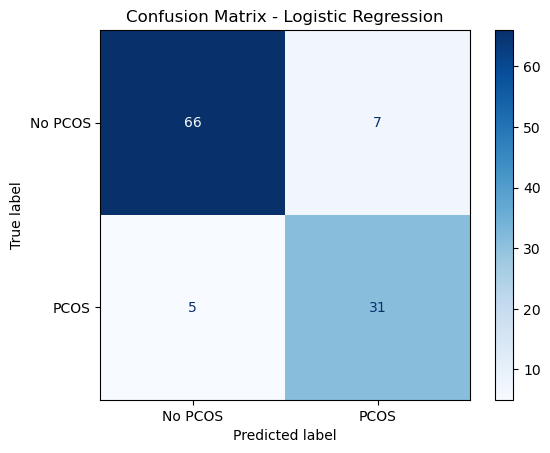

In [36]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No PCOS", "PCOS"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

The confusion matrix shows that the Logistic Regression model correctly classified **66 patients without PCOS** and **31 patients with PCOS**.

The model produced **7 false positives**, where non-PCOS patients were incorrectly classified as having PCOS, and **5 false negatives**, where patients with PCOS were missed.

Overall, the model demonstrated strong predictive performance, with relatively few misclassifications and a high ability to identify patients with PCOS.

### Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that builds multiple decision trees using random subsets of the training data and features. The final prediction is determined by combining the predictions of all trees through majority voting, making the model more robust and less prone to overfitting than a single decision tree.

In this project, the Random Forest classifier is trained to predict whether a patient has PCOS based on demographic, clinical, hormonal, and lifestyle features. After training, its performance is evaluated using the same metrics as the Logistic Regression model to enable an objective comparison in the final section.

In [37]:
# Training the Random Forest Model
from sklearn.ensemble import RandomForestClassifier

# Initialize model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

print(rf)

RandomForestClassifier(random_state=42)


In [38]:
# Predictions
y_pred_rf = rf.predict(X_test)

# Probability predictions
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [39]:
# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results_rf = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Score":[
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results_rf

,Metric,Score
0,Accuracy,0.899083
1,Precision,0.903226
2,Recall,0.777778
3,F1-score,0.835821
4,ROC-AUC,0.947679


The Random Forest classifier achieved an accuracy of 89.9%, indicating strong overall performance in distinguishing patients with and without PCOS. The model correctly classified 98 out of 109 patients in the test dataset.

Compared with Logistic Regression, Random Forest achieved slightly higher overall accuracy and precision, while Logistic Regression demonstrated a higher recall for identifying PCOS cases.

In [40]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.90      0.96      0.93        73
           1       0.90      0.78      0.84        36

    accuracy                           0.90       109
   macro avg       0.90      0.87      0.88       109
weighted avg       0.90      0.90      0.90       109



The classification report shows that the model performs well for both classes.

For No PCOS (Class 0):

- Precision: 0.90
- Recall: 0.96
- F1-score: 0.93

For PCOS (Class 1):

- Precision: 0.90
- Recall: 0.78
- F1-score: 0.84

The model is highly effective at identifying patients without PCOS and maintains good precision for detecting PCOS. However, the lower recall for the PCOS class indicates that some positive cases are still missed, which is an important consideration in medical screening applications.

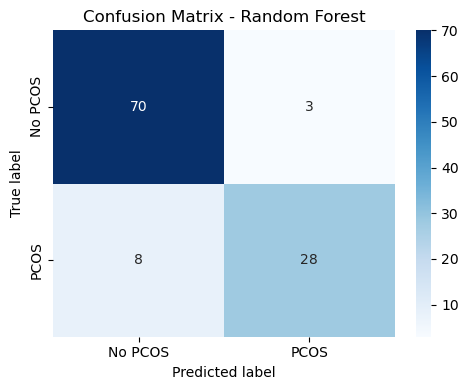

In [41]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No PCOS","PCOS"],
    yticklabels=["No PCOS","PCOS"]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - Random Forest")

plt.tight_layout()
plt.show()

The confusion matrix shows that the model correctly identified:

- 70 patients without PCOS (True Negatives)
- 28 patients with PCOS (True Positives)

The model incorrectly classified:

- 3 non-PCOS patients as PCOS (False Positives)
- 8 PCOS patients as non-PCOS (False Negatives)

Overall, the Random Forest model made relatively few incorrect predictions, although a small number of PCOS cases were missed.

In [42]:
# Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
37,Follicle No. (R),0.186993
36,Follicle No. (L),0.128029
27,Weight gain(Y/N),0.056929
29,Skin darkening (Y/N),0.056510
28,hair growth(Y/N),0.050687
22,AMH(ng/mL),0.034668
9,Cycle length(days),0.028483
8,Cycle(R/I),0.025246
17,FSH/LH,0.025161
3,BMI,0.021665


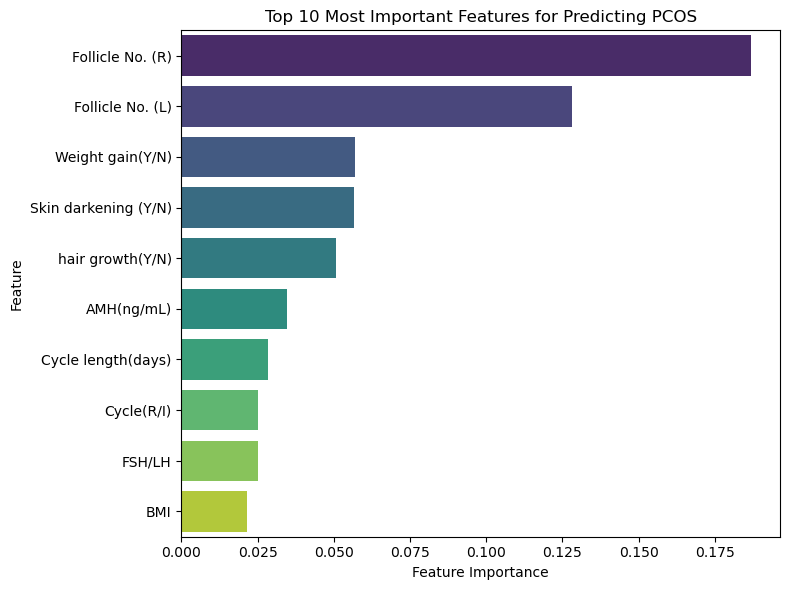

In [43]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    palette="viridis",
    hue="Feature",
    legend=False
)

plt.title("Top 10 Most Important Features for Predicting PCOS")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

The feature importance plot highlights the variables that contributed the most to the Random Forest model's predictions.

The number of follicles in the right and left ovaries emerged as the two most influential features, indicating that ovarian follicle count is the strongest predictor of PCOS in this dataset.

Other highly important features include weight gain, skin darkening, hair growth, and AMH levels, all of which are well-recognized clinical characteristics associated with PCOS. Menstrual characteristics such as cycle length and cycle regularity, along with the FSH/LH ratio and BMI, also contributed to the model, although to a lesser extent.

Overall, the model relies on a combination of ultrasound findings, hormonal measurements, metabolic indicators, and clinical symptoms rather than a single variable, reflecting the multifactorial nature of PCOS.

## Key Takeway

The Random Forest model achieved strong predictive performance (89.9% accuracy and ROC-AUC of 0.948) while identifying clinically relevant predictors such as follicle count, AMH, menstrual irregularity, and hyperandrogenic symptoms. Although the model produced slightly higher overall accuracy than Logistic Regression, it showed lower recall for PCOS cases, indicating a greater tendency to miss some positive patients. Depending on the clinical objective, Logistic Regression may be preferred for maximizing case detection, whereas Random Forest provides better overall classification accuracy and valuable insights into feature importance.

## Model Comparison

In this section, the performance of Logistic Regression and Random Forest is compared using multiple evaluation metrics. Comparing different models helps identify the approach that provides the best balance between predictive performance and clinical applicability.

In [49]:
# Calculating metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Logistic Regression
log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)
log_auc = roc_auc_score(y_test, y_prob_log)

# Random Forest
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

In [50]:
# Comparison table
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Logistic Regression": [
        log_accuracy,
        log_precision,
        log_recall,
        log_f1,
        log_auc
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_auc
    ]
})

comparison = comparison.round(3)
comparison

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.890,0.899
1,Precision,0.816,0.903
2,Recall,0.861,0.778
3,F1-score,0.838,0.836
4,ROC-AUC,0.951,0.948


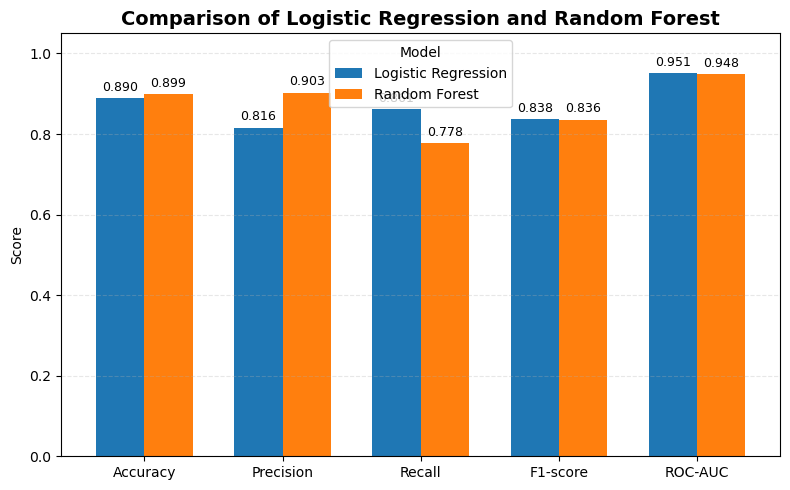

In [51]:
comparison_plot = comparison.set_index("Metric")

ax = comparison_plot.plot(
    kind="bar",
    figsize=(8,5),
    width=0.7,
    rot=0
)

plt.title("Comparison of Logistic Regression and Random Forest", fontsize=14, weight="bold")
plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(title="Model", frameon=True)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

- Both models achieved high predictive performance, with an accuracy of approximately 90% on the test dataset.
- Random Forest achieved the highest overall Accuracy (89.9%) and Precision (90.3%), indicating it produced fewer false positive predictions than Logistic Regression.
- Logistic Regression achieved a higher Recall (86.1%), meaning it correctly identified a larger proportion of patients with PCOS and produced fewer false negatives.
- The F1-scores of both models were nearly identical (≈0.84), demonstrating a balanced trade-off between precision and recall.
- Both models also achieved excellent ROC-AUC values (≈0.95), indicating strong ability to distinguish between patients with and without PCOS across different classification thresholds.

## Key Takeaways
- Logistic Regression provides a simple and highly interpretable baseline model while maintaining strong predictive performance.
- Random Forest slightly improves overall classification accuracy and precision by capturing non-linear relationships between clinical features.
- Since identifying patients with PCOS is clinically important, the higher recall achieved by Logistic Regression may be advantageous in screening applications where missing positive cases should be minimized.
- Overall, both models demonstrated strong predictive capability, with Random Forest performing slightly better overall and Logistic Regression offering better sensitivity to positive cases.

## Conclusion

The machine learning analysis demonstrated that PCOS can be predicted with high accuracy using routinely collected clinical, hormonal, and ultrasound measurements. Among the evaluated models, Random Forest achieved the best overall performance, while Logistic Regression provided comparable results with greater interpretability. These findings suggest that machine learning techniques can effectively support early identification of PCOS and may serve as valuable decision-support tools in clinical settings.

# Project Summary

This project analyzed clinical and hormonal data from 541 patients to predict the presence of PCOS.

Key outcomes include:

- Performed end-to-end data cleaning, preprocessing, exploratory data analysis, and statistical testing.
- Identified significant predictors such as follicle count, AMH levels, BMI, weight gain, and skin darkening.
- Built and evaluated Logistic Regression and Random Forest classification models.
- Random Forest achieved the best overall performance with approximately 90% accuracy, while Logistic Regression achieved higher recall for detecting PCOS cases.
- The project demonstrates a complete machine learning workflow, from raw clinical data to predictive modeling and interpretation.